# Multiclass Semantic Similarity Analysis

This notebook generates two key plots for semantic similarity analysis:
1. Quartile-based distribution of negative class error normalized by most similar positive GT count
2. Pearson correlation coefficients for negative label test by model

## 1. Setup and Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import clip
from scipy.stats import pearsonr, spearmanr
from table_utils import get_model_color, get_shortened_name

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 2. Configuration

In [2]:
# Configuration
DATA_DIR = "data/multiclass-dataset"
BENCHMARK_RESULTS_DIR = "multiclass_benchmark_results"
OUTPUT_DIR = "plots/semantic-distance"

# Model selection
MODELS_TO_ANALYZE = [
    'CLIP-Count',
    'CounTX',
    'CountGD',
    'DAVE',
    'FixedPointPromptCounting',
    'GroundingREC',
    'PseCo',
    'TFPOC',
    'VLCounter',
    'ZSC',
]

# CLIP model
CLIP_MODEL_NAME = "ViT-B/32"

# Number of similarity bins
N_BINS = 5

print(f"Analyzing {len(MODELS_TO_ANALYZE)} models")
print(f"Using CLIP model: {CLIP_MODEL_NAME}")
print(f"Output directory: {OUTPUT_DIR}")

Analyzing 10 models
Using CLIP model: ViT-B/32
Output directory: plots/semantic-distance


## 3. Load CLIP Model and Compute Text Embeddings

In [3]:
# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clip_model, preprocess = clip.load(CLIP_MODEL_NAME, device=device)
print(f"Loaded CLIP model: {CLIP_MODEL_NAME}")

Using device: cuda
Loaded CLIP model: ViT-B/32


In [4]:
# Load class list from one of the test files
sample_model = MODELS_TO_ANALYZE[0]
sample_csv_path = os.path.join(BENCHMARK_RESULTS_DIR, sample_model, f'multiclass_{sample_model}_test1.csv')
sample_df = pd.read_csv(sample_csv_path, index_col=0)
all_classes = sample_df.columns.tolist()

print(f"Total classes: {len(all_classes)}")

Total classes: 45


In [5]:
# Compute CLIP text embeddings for all classes
PREFIX_PROMPT = "a photo of "
def get_text_prompt(class_name):
    """Convert class name to text prompt"""
    return PREFIX_PROMPT + class_name

# Tokenize and encode all class names
class_prompts = [get_text_prompt(c) for c in all_classes]
text_tokens = clip.tokenize(class_prompts).to(device)

with torch.no_grad():
    text_embeddings = clip_model.encode_text(text_tokens)
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)  # Normalize

# Convert to numpy for easier manipulation
text_embeddings_np = text_embeddings.cpu().numpy()

# Create a dictionary mapping class names to embeddings
class_embeddings = {class_name: text_embeddings_np[i] for i, class_name in enumerate(all_classes)}

print(f"Computed embeddings for {len(class_embeddings)} classes")
print(f"Embedding dimension: {text_embeddings_np.shape[1]}")

Computed embeddings for 45 classes
Embedding dimension: 512


In [6]:
# Function to compute cosine similarity
def cosine_similarity(emb1, emb2):
    """Compute cosine similarity between two embeddings (already normalized)"""
    return np.dot(emb1, emb2)

## 4. Load Ground Truth and Image-Class Mappings

In [7]:
# Load ground truth counts per class
gt_json_path = os.path.join(DATA_DIR, "multiclass_class_counts_per_image.json")
with open(gt_json_path, 'r') as f:
    gt_counts_per_class = json.load(f)

# Load image-to-classes mapping
img_class_txt_path = os.path.join(DATA_DIR, "multiclass_image_classes.txt")
img_classes = {}
with open(img_class_txt_path, 'r') as file:
    for line in file:
        line = line.strip().split('\t')
        if len(line) == 2:
            img_name, classes_str = line
            classes_list = [cls.strip() for cls in classes_str.split(',')]
            img_classes[img_name] = classes_list

print(f"Loaded ground truth for {len(gt_counts_per_class)} images")
print(f"Loaded class mappings for {len(img_classes)} images")

Loaded ground truth for 200 images
Loaded class mappings for 200 images


## 5. Process All Models and Create Analysis Dataset

In [8]:
def compute_error_metrics(pred, gt):
    """Compute various error metrics"""
    metrics = {}
    
    # Absolute error
    metrics['absolute'] = abs(pred - gt)
    
    # MAE (same as absolute for single prediction)
    metrics['mae'] = abs(pred - gt)
    
    # RMSE (same as absolute for single prediction, but squared)
    metrics['rmse'] = (pred - gt) ** 2
    
    # Normalized versions
    if gt > 0:
        metrics['normalized_mae'] = abs(pred - gt) / gt
        metrics['normalized_rmse'] = ((pred - gt) / gt) ** 2
    else:
        metrics['normalized_mae'] = abs(pred - gt) if pred > 0 else 0
        metrics['normalized_rmse'] = (pred ** 2) if pred > 0 else 0
    
    return metrics

In [9]:
# Create comprehensive analysis dataset
analysis_data = []

for model_name in tqdm(MODELS_TO_ANALYZE, desc="Processing models"):
    # Load predictions
    pred_csv_path = os.path.join(BENCHMARK_RESULTS_DIR, model_name, f'multiclass_{model_name}_test1.csv')
    
    if not os.path.exists(pred_csv_path):
        print(f"Warning: Predictions not found for {model_name}")
        continue
    
    pred_df = pd.read_csv(pred_csv_path, index_col=0)
    
    # Process each image
    for img_name in pred_df.index:
        if img_name not in img_classes or img_name not in gt_counts_per_class:
            continue
        
        positive_classes = img_classes[img_name]
        negative_classes = [c for c in all_classes if c not in positive_classes]
        
        # === NEGATIVE LABEL TEST ===
        # For each negative class, compute similarity to positive classes
        for neg_class in negative_classes:
            pred_count = pred_df.loc[img_name, neg_class]
            gt_count = 0  # Ground truth is always 0 for negative classes
            
            # Compute similarities to all positive classes
            similarities_to_positive = []
            for pos_class in positive_classes:
                sim = cosine_similarity(class_embeddings[neg_class], class_embeddings[pos_class])
                similarities_to_positive.append(sim)
            
            # Aggregate similarity metrics
            max_sim_to_positive = max(similarities_to_positive) if similarities_to_positive else 0
            avg_sim_to_positive = np.mean(similarities_to_positive) if similarities_to_positive else 0
            
            # Compute error metrics
            errors = compute_error_metrics(pred_count, gt_count)
            
            # Add to dataset
            row = {
                'model': model_name,
                'image': img_name,
                'test_type': 'negative_label',
                'class': neg_class,
                'is_positive': False,
                'pred_count': pred_count,
                'gt_count': gt_count,
                'num_positive_classes': len(positive_classes),
                'max_sim_to_positive': max_sim_to_positive,
                'avg_sim_to_positive': avg_sim_to_positive,
                'self_similarity': 1.0,
            }
            row.update(errors)
            analysis_data.append(row)

# Create DataFrame
df_analysis = pd.DataFrame(analysis_data)
print(f"\nCreated analysis dataset with {len(df_analysis)} rows")
print(f"Test types: {df_analysis['test_type'].value_counts()}")

Processing models: 100%|██████████| 10/10 [00:01<00:00,  5.68it/s]



Created analysis dataset with 84900 rows
Test types: test_type
negative_label    84900
Name: count, dtype: int64


## 6. Prepare Data for Plotting

In [10]:
# Filter for negative label test
df_neg = df_analysis[df_analysis['test_type'] == 'negative_label'].copy()

print(f"Negative label test: {len(df_neg)} data points")
print(f"Models: {df_neg['model'].unique()}")

Negative label test: 84900 data points
Models: ['CLIP-Count' 'CounTX' 'CountGD' 'DAVE' 'FixedPointPromptCounting'
 'GroundingREC' 'PseCo' 'TFPOC' 'VLCounter' 'ZSC']


In [12]:
# Create binned similarity analysis
df_neg_binned = df_neg.copy()

# convert df_neg_binned['max_sim_to_positive'] to float32
df_neg_binned['max_sim_to_positive'] = df_neg_binned['max_sim_to_positive'].astype(float)

# Bin the max_sim_to_positive values into N_BINS bins
df_neg_binned['similarity_bin'] = pd.cut(
    df_neg_binned['max_sim_to_positive'], 
    bins=N_BINS, 
    labels=[f'Bin {i+1}' for i in range(N_BINS)]
)

# Get bin edges for labels
bin_edges = pd.cut(df_neg_binned['max_sim_to_positive'], bins=N_BINS, retbins=True)[1]
bin_labels = [f'{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}' for i in range(N_BINS)]

print(f"Created {N_BINS} similarity bins")
print(f"Bin ranges: {bin_labels}")

Created 5 similarity bins
Bin ranges: ['0.50-0.58', '0.58-0.67', '0.67-0.75', '0.75-0.83', '0.83-0.92']


In [13]:
# Normalize error by most similar positive class GT count
df_neg_binned_pos_norm = df_neg_binned.copy()

most_similar_positive_class = []
most_similar_positive_gt_count = []
error_normalized_by_positive_gt = []

for idx, row in df_neg_binned_pos_norm.iterrows():
    img_name = row['image']
    neg_class = row['class']
    
    # Get positive classes for this image
    positive_classes = img_classes[img_name]
    
    # Find the positive class with maximum similarity to this negative class
    max_sim = -1
    best_pos_class = None
    for pos_class in positive_classes:
        sim = cosine_similarity(class_embeddings[neg_class], class_embeddings[pos_class])
        if sim > max_sim:
            max_sim = sim
            best_pos_class = pos_class
    
    # Get GT count for that positive class
    pos_gt_count = gt_counts_per_class[img_name][best_pos_class]
    
    # Compute normalized error
    if pos_gt_count > 0:
        norm_error = row['absolute'] / pos_gt_count
    else:
        norm_error = row['absolute']
    
    most_similar_positive_class.append(best_pos_class)
    most_similar_positive_gt_count.append(pos_gt_count)
    error_normalized_by_positive_gt.append(norm_error)

df_neg_binned_pos_norm['most_similar_positive_class'] = most_similar_positive_class
df_neg_binned_pos_norm['most_similar_positive_gt_count'] = most_similar_positive_gt_count
df_neg_binned_pos_norm['error_norm_by_pos_gt'] = error_normalized_by_positive_gt

print(f"Computed normalization by most similar positive class GT count")

Computed normalization by most similar positive class GT count


In [14]:
# Compute correlation statistics per model
correlation_results = []

for model in MODELS_TO_ANALYZE:
    df_model_neg = df_neg[df_neg['model'] == model]
    
    if len(df_model_neg) > 10:
        # Filter out NaN and Inf values
        valid_mask = np.isfinite(df_model_neg['max_sim_to_positive']) & np.isfinite(df_model_neg['absolute'])
        valid_sim = df_model_neg['max_sim_to_positive'][valid_mask]
        valid_error = df_model_neg['absolute'][valid_mask]
        
        if len(valid_sim) >= 10:
            pearson_r, pearson_p = pearsonr(valid_sim, valid_error)
            spearman_r, spearman_p = spearmanr(valid_sim, valid_error)
            correlation_results.append({
                'model': model,
                'test': 'negative_label',
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'spearman_r': spearman_r,
                'spearman_p': spearman_p,
            })

df_correlations = pd.DataFrame(correlation_results)
print(f"\nComputed correlations for {len(df_correlations)} models")


Computed correlations for 10 models


## 7. Plot 1: Quartile-based Distribution per Model

Negative Class Error Normalized by Most Similar Positive GT Count
(Quartile-based distribution per similarity bin)


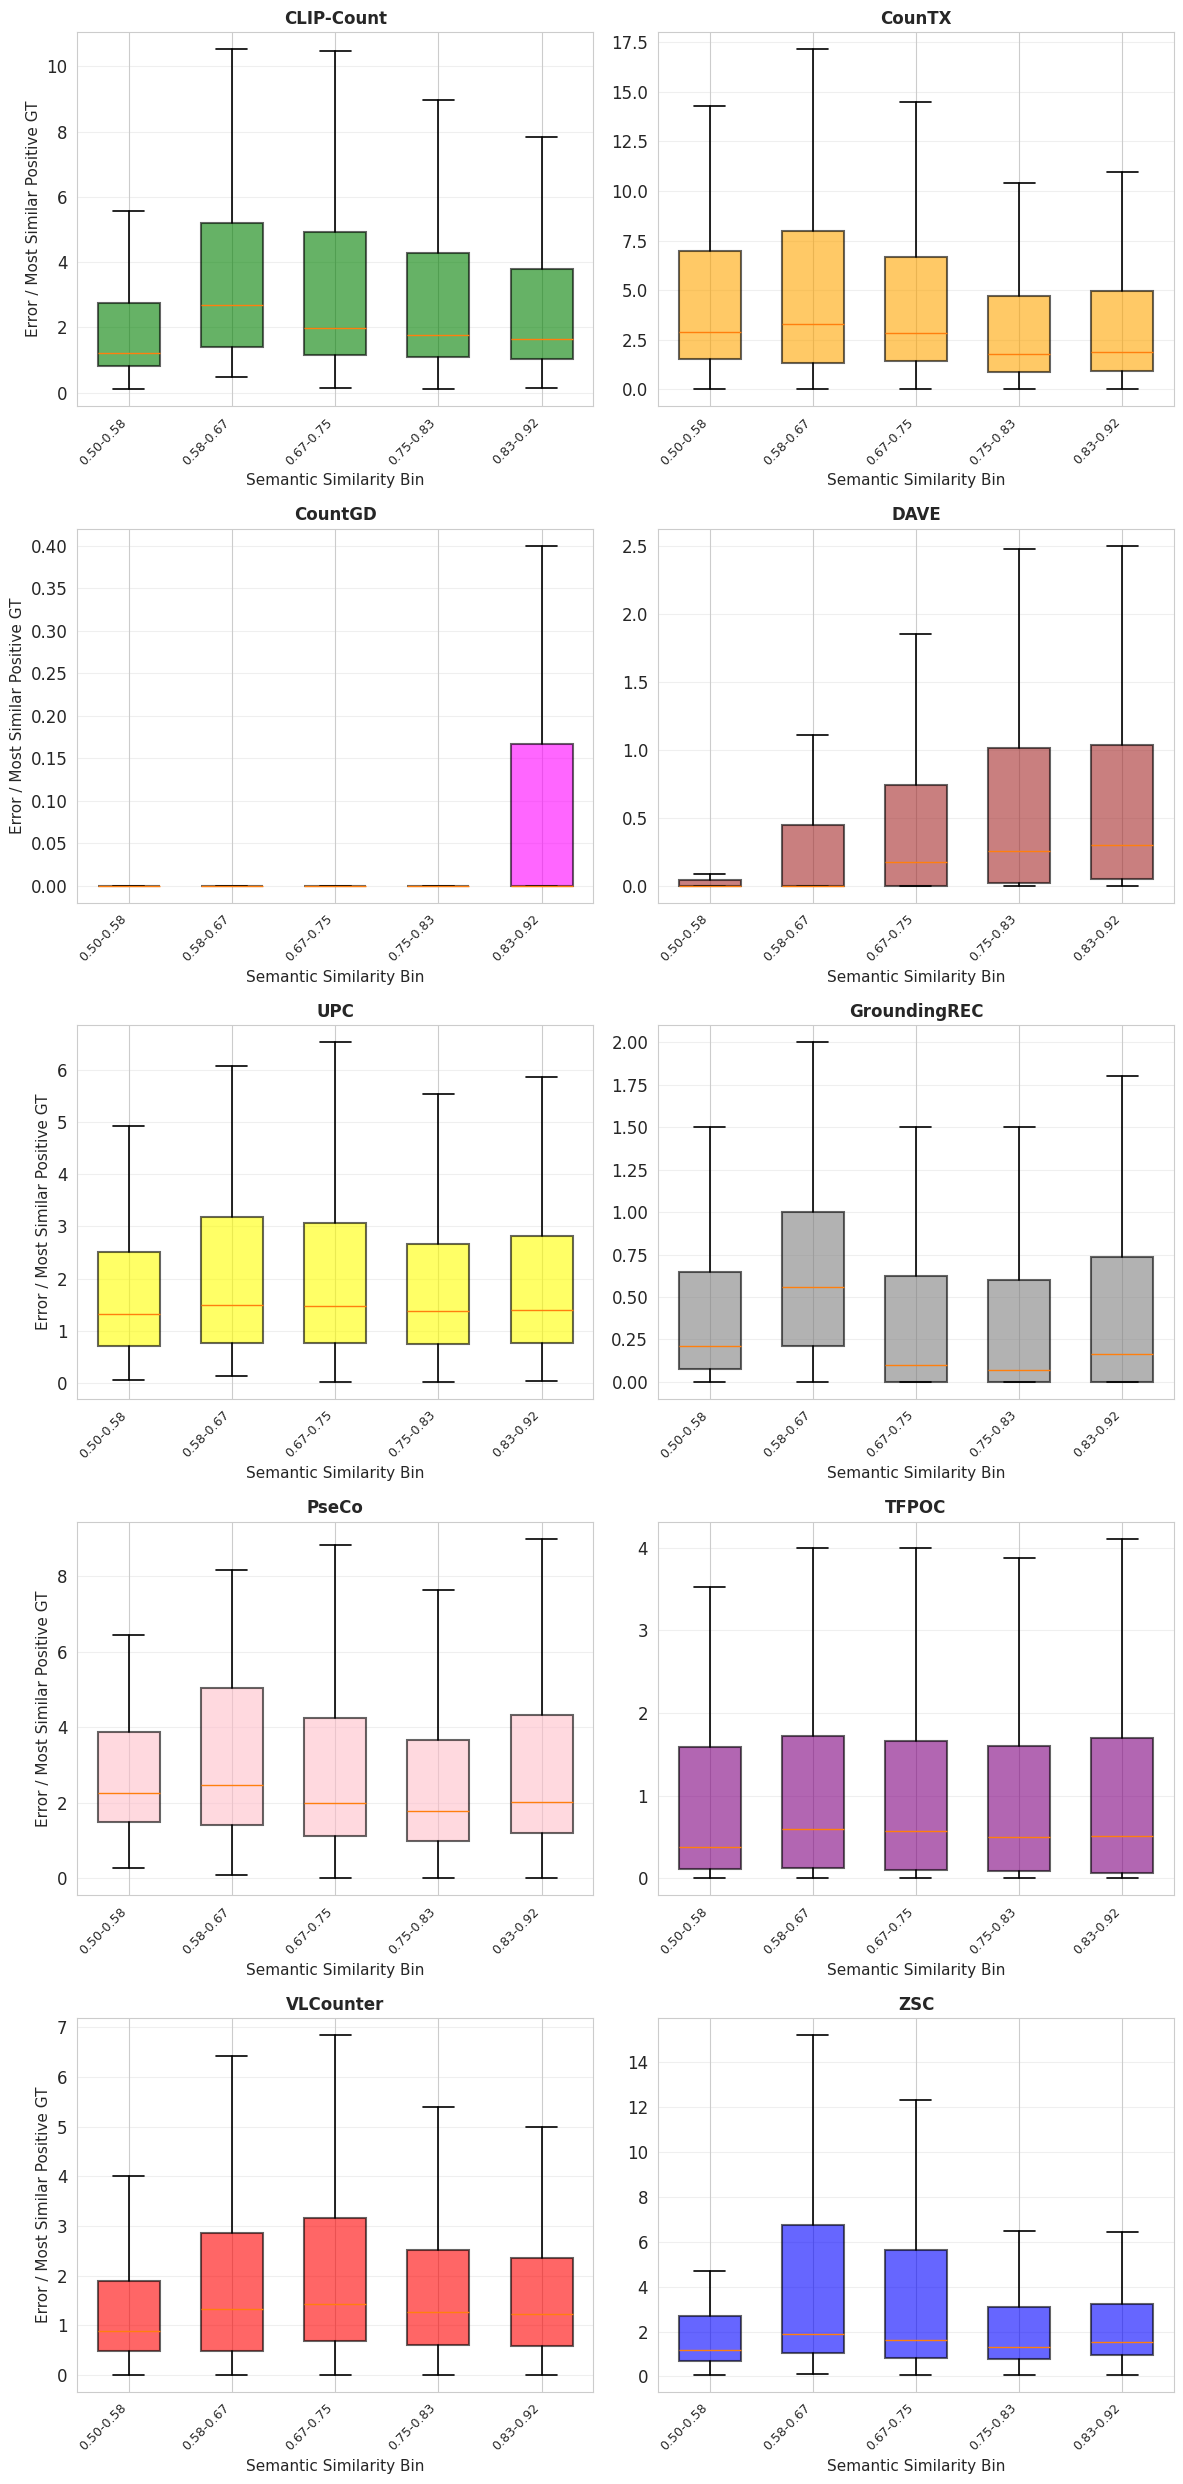


Saved plot: plots/semantic-distance/binned_similarity_vs_pos_normalized_error_per_model_quartiles_vert.pdf


In [15]:
MAKE_VERTICAL = True

n_models = len(MODELS_TO_ANALYZE)
if not MAKE_VERTICAL:
    n_cols = 5
else:
    n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows) if not MAKE_VERTICAL else (12, 5 * n_rows))
axes = axes.flatten()

shared_y_scale = False
if shared_y_scale:
    global_min = df_neg_binned_pos_norm['error_norm_by_pos_gt'].min()
    global_max = 16
    y_margin = (global_max - global_min) * 0.1
    y_limits = (max(0, global_min - y_margin), global_max + y_margin)
else:    
    y_limits = None

for idx, model in enumerate(MODELS_TO_ANALYZE):
    ax = axes[idx]

    df_model = df_neg_binned_pos_norm[
        df_neg_binned_pos_norm['model'] == model
    ].copy()

    if df_model.empty:
        ax.text(0.5, 0.5, f'{model}\nNo data',
                ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    if model == "FixedPointPromptCounting":
        plot_model = "UPC"
    else:
        plot_model = model

    # Collect data per bin (raw values, not aggregated)
    data_per_bin = [
        df_model.loc[
            df_model['similarity_bin'] == bin_,
            'error_norm_by_pos_gt'
        ].dropna().values
        for bin_ in df_model['similarity_bin'].cat.categories
    ]

    # Boxplot (quartiles)
    bp = ax.boxplot(
        data_per_bin,
        patch_artist=True,
        widths=0.6,
        showfliers=False,
        meanprops=dict(color='red', linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )

    # Color styling
    color = get_model_color(plot_model)
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_alpha(0.6)
        box.set_edgecolor('black')

    # Labels & formatting
    ax.set_xlabel('Semantic Similarity Bin', fontsize=11)
    if idx % n_cols == 0:
        ax.set_ylabel('Error / Most Similar Positive GT', fontsize=11)

    ax.set_title(plot_model, fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(1, len(bin_labels) + 1))
    ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    if y_limits is not None:
        ax.set_ylim(y_limits)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

title = (
    'Negative Class Error Normalized by Most Similar Positive GT Count\n'
    '(Quartile-based distribution per similarity bin)'
)
print(title)

suffix = "" if not MAKE_VERTICAL else "_vert"
plt.tight_layout()
output_path = os.path.join(OUTPUT_DIR, f'binned_similarity_vs_pos_normalized_error_per_model_quartiles{suffix}.pdf')
plt.savefig(output_path, dpi=500, bbox_inches='tight')
plt.show()

print(f"\nSaved plot: {output_path}")

## 8. Plot 2: Pearson Correlation by Model (Negative Label Test)

Negative Label Test: Similarity vs. Error
Correlation by Model


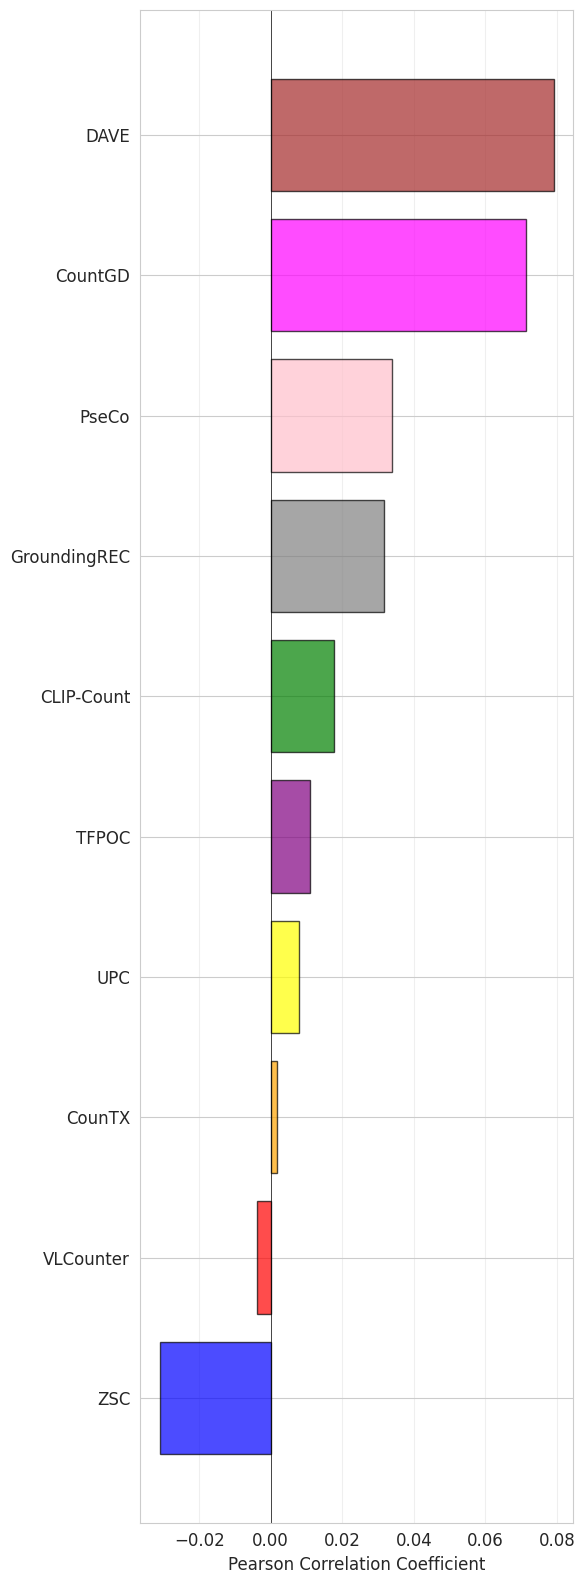


Saved plot: plots/semantic-distance/correlation_comparison_by_model_vert.pdf


In [16]:
MAKE_VERTICAL = True
if not MAKE_VERTICAL:
    fig, axes = plt.subplots(1, 1, figsize=(16, 6))
else:
    fig, axes = plt.subplots(1, 1, figsize=(6, 16))

ax = axes
df_neg_corr = df_correlations[df_correlations['test'] == 'negative_label'].copy()
df_neg_corr = df_neg_corr.sort_values('pearson_r')
x_pos = np.arange(len(df_neg_corr))
ax.barh(x_pos, df_neg_corr['pearson_r'], alpha=0.7, 
        color=[get_model_color(i) for i in df_neg_corr['model']], 
        label='Pearson', edgecolor='black', linewidth=1.0)
ax.set_yticks(x_pos)
ax.set_yticklabels([get_shortened_name(i) for i in df_neg_corr['model']])
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
title = 'Negative Label Test: Similarity vs. Error\nCorrelation by Model'
print(title)
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
suffix = '' if not MAKE_VERTICAL else '_vert' 
output_path = os.path.join(OUTPUT_DIR, f'correlation_comparison_by_model{suffix}.pdf')
plt.savefig(output_path, dpi=400, bbox_inches='tight')
plt.show()

print(f"\nSaved plot: {output_path}")